### **MLE(s)**

#### **Objective**

Visualize the Maximum Likelihood Estimation (MLE) for three specific probability distributions by generating synthetic data and plotting the likelihood or log-likelihood functions. Specifically:
1. For the Pareto-style distribution $f_{\theta}(x) = r\theta^r x^{-(r+1)}$, verify that the MLE $\hat{\theta}$ occurs at $\min(X_i)$.
2. For the Beta-like distribution $f_{\theta}(x) = \sqrt{\theta}x^{\sqrt{\theta}-1}$, confirm the peak aligns with the estimator $\hat{\theta} = \left(\frac{n}{\sum \ln(X_i)}\right)^2$.
3. For the Exponential-Weibull distribution *$f_{\theta}(x) = \theta r x^{r-1} \exp(-\theta x^r)$*, confirm the MLE $\hat{\theta} = \frac{n}{\sum X_i^r}$.

All visualizations should include vertical lines indicating the calculated MLEs to provide visual evidence for the mathematical derivations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#### **MLE for Pareto-style Distribution**

Let $X_1, \dots, X_n$ be i.i.d. random variables with PDF $f(x; \theta)$.
- The distribution function is given by $f_{\theta}(x) = r\theta^r x^{-(r+1)}$

Generate synthetic data and plot the likelihood function for the Pareto-style distribution to verify the MLE occurs at the minimum value.


- We generate the data using the transformation
$X = \theta (1 - U)^{-1/\alpha}$, which ensures that $X \ge \theta$. [Note: To generate synthetic data following a Pareto distribution, we apply the inverse transform method:
$X = \theta (1 - U)^{-\frac{1}{\alpha}}$
where $U \sim \text{Uniform}(0, 1)$.  This transformation ensures that the support of the distribution is $X \in [\theta, \infty)$, satisfying the condition $X \ge \theta$.]

- Likelihood Function
$L(\theta) = r^n \theta^{nr} \prod_{i=1}^{n} x_i^{-(r+1)}$

- Log-Likelihood Function
$\ell(\theta) = n \ln(r) + nr \ln(\theta) - (r+1) \sum_{i=1}^{n} \ln(x_i)$

- Proportionality for visualization
$L(\theta) \propto \theta^{nr}$

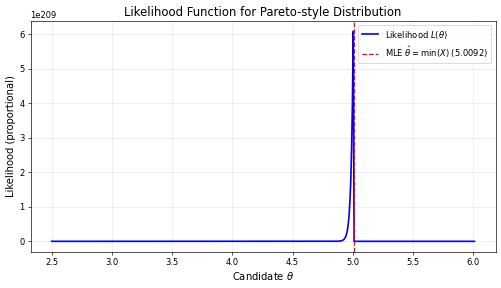

True theta: 5.0 
Minimum of sample (MLE): 5.009237556709652


In [2]:
# Parameters
r, true_theta, n = 3.0, 5.0, 100

# Generate synthetic data: X = theta * (1 - U)^(-1/r), this ensures x >= theta
np.random.seed(42)
u = np.random.uniform(0, 1, n)
x = true_theta * (1 - u)**(-1/r)
min_x = np.min(x)

# Define Likelihood function
def calculate_likelihood(theta_cand, x_data, r_param):
    n_samples = len(x_data)
    if theta_cand > np.min(x_data):
        return 0.0
    return (theta_cand**(n_samples * r_param))

# Candidate theta values
theta_range = np.linspace(true_theta * 0.5, min_x + 1.0, 500)
likelihood_values = [calculate_likelihood(t, x, r) for t in theta_range]

# Plotting
plt.figure(figsize=(10, 5), dpi=60)
plt.plot(theta_range, likelihood_values, label='Likelihood $L(\\theta)$', color='blue', lw=2)
plt.axvline(x=min_x, color='red', linestyle='--', label=f'MLE $\\hat{{\\theta}} = \\min(X)$ ({min_x:.4f})')

plt.title('Likelihood Function for Pareto-style Distribution', fontsize=14)
plt.xlabel('Candidate $\\theta$', fontsize=12)
plt.ylabel('Likelihood (proportional)', fontsize=12)
plt.legend() ; plt.grid(True, alpha=0.3) ; plt.show()

print(f'True theta: {true_theta} \nMinimum of sample (MLE): {min_x}')

#### **MLE for Beta-like Distribution**

Let $X_1, \dots, X_n$ be i.i.d. random variables with PDF $f(x; \theta)$.
- The distribution function is given by $f_{\theta}(x) = \sqrt{\theta}x^{\sqrt{\theta}-1}$

Generate synthetic data for a Beta-like distribution to verify the MLE $\hat{\theta} = (n / \sum \ln(X_i))^2$.

Maximum Likelihood Estimation for $f(x; \theta)$

Given the probability density function for $X \in (0, 1)$ and $\theta > 0$, $f(x; \theta) = \sqrt{\theta} x^{\sqrt{\theta} - 1} \mathbb{I}_{(0 < x < 1)} $


Likelihood Function: For an i.i.d. sample $X_1, X_2, \dots, X_n$, the likelihood function is
- $L(\theta) = \prod_{i=1}^{n} \sqrt{\theta} X_i^{\sqrt{\theta} - 1} = \theta^{n/2} \prod_{i=1}^{n} X_i^{\sqrt{\theta} - 1}$

Log-Likelihood Function: Taking the natural logarithm to simplify optimization:
- $\ell(\theta) = \frac{n}{2} \ln(\theta) + (\sqrt{\theta} - 1) \sum_{i=1}^{n} \ln(X_i)$

Finding the MLE: We take the derivative with respect to $\theta$ and set it to zero
- $\frac{d\ell}{d\theta} = \frac{n}{2\theta} + \frac{1}{2\sqrt{\theta}} \sum_{i=1}^{n} \ln(X_i) = 0$.

Isolating the terms
- $\frac{n}{\theta} = - \frac{\sum_{i=1}^{n} \ln(X_i)}{\sqrt{\theta}}$. Multiplying both sides by $\theta$ and dividing by $-\sum \ln(X_i)$ $\sqrt{\theta} = \frac{n}{-\sum_{i=1}^{n} \ln(X_i)}$

Final Estimate, squaring both sides yields the MLE
-  $\hat{\theta}_{MLE} = \left( \frac{n}{\sum_{i=1}^{n} \ln(X_i)} \right)^2 = \frac{n^2}{\left( \sum_{i=1}^{n} \ln(X_i) \right)^2}$

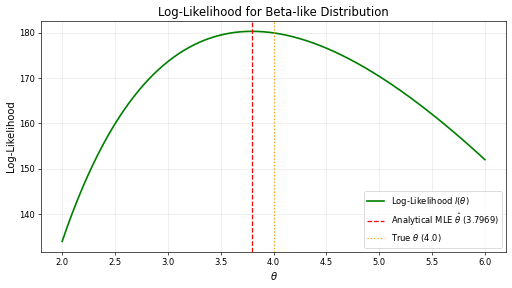

True Theta: 4.0 
Analytical MLE: 3.79694213245309


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
true_theta, n  = 4.0, 1000
np.random.seed(42)

# Generate synthetic data with Inverse Transform Sampling X = U^(1/sqrt(theta))
u = np.random.uniform(0, 1, n)
x_beta = u**(1 / np.sqrt(true_theta))

# Implement log-likelihood function
def beta_log_likelihood(theta_cand, data):
    n_samples = len(data)
    sum_ln_x = np.sum(np.log(data))
    # l(theta) = (n/2)ln(theta) + (sqrt(theta)-1) * sum(ln(x_i))
    return (n_samples / 2) * np.log(theta_cand) + (np.sqrt(theta_cand) - 1) * sum_ln_x

# Calculate analytical MLE: theta_hat = (n / sum(ln(X_i)))^2
sum_ln_x_val = np.sum(np.log(x_beta))
mle_theta_beta = (n / sum_ln_x_val)**2

# Generate candidate values and calculate log-likelihoods
theta_range_beta = np.linspace(max(0.1, true_theta - 2), true_theta + 2, 500)
log_lik_values = [beta_log_likelihood(t, x_beta) for t in theta_range_beta]

plt.figure(figsize=(10, 5), dpi=60)
plt.plot(theta_range_beta, log_lik_values, label='Log-Likelihood $l(\\theta)$', color='green', lw=2)
plt.axvline(x=mle_theta_beta, color='red', linestyle='--', label=f'Analytical MLE $\\hat{{\\theta}}$ ({mle_theta_beta:.4f})')
plt.axvline(x=true_theta, color='orange', linestyle=':', label=f'True $\\theta$ ({true_theta})')

plt.title('Log-Likelihood for Beta-like Distribution', fontsize=14)
plt.xlabel('$\\theta$', fontsize=12) ; plt.ylabel('Log-Likelihood', fontsize=12)
plt.legend() ; plt.grid(True, alpha=0.3) ; plt.show()

print(f'True Theta: {true_theta} \nAnalytical MLE: {mle_theta_beta}')

### **MLE for Exponential-Weibull Distribution**

Let $X_1, \dots, X_n$ be i.i.d. random variables with PDF $f(x; \theta)$.
- $f_{\theta}(x) = \theta r x^{r-1} \exp(-\theta x^r)$

Generate synthetic data for the Exponential-Weibull distribution and plot the log-likelihood function to confirm the MLE estimator $\hat{\theta} = n / \sum X_i^r$.


MLE for the Weibull-type Distribution

The likelihood function for $\theta$:
- $L(\theta) = \theta^n r^n \left( \prod_{i=1}^{n} X_i^{r-1} \right) \exp\left( -\theta \sum_{i=1}^{n} X_i^r \right)$

The log-likelihood:
- $\ell(\theta) = n \ln(\theta) + n \ln(r) + (r-1) \sum_{i=1}^{n} \ln(X_i) - \theta \sum_{i=1}^{n} X_i^r$

Taking the derivative with respect to $\theta$:
- $\frac{d\ell}{d\theta} = \frac{n}{\theta} - \sum_{i=1}^{n} X_i^r = 0$

The Maximum Likelihood Estimator:
- $\hat{\theta}_{MLE} = \frac{n}{\sum_{i=1}^{n} X_i^r}$


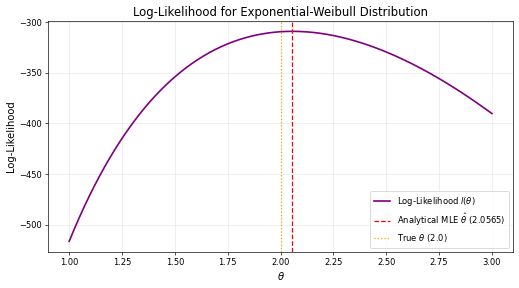

True Theta: 2.0 
Analytical MLE: 2.0565426917795238


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
true_theta, r_param, n = 2.0, 1.5, 1000
np.random.seed(42)

# Generate synthetic data w/ Inverse Transform Sampling X=(-ln(1-U)/theta)^(1/r)
u = np.random.uniform(0, 1, n)
x_weibull = (-np.log(1 - u) / true_theta)**(1 / r_param)

# Define log-likelihood function
def weibull_log_likelihood(theta_cand, data, r):
    n_samples = len(data)
    sum_ln_x = np.sum(np.log(data))
    sum_x_pow_r = np.sum(data**r)
    # l(theta) = n*ln(theta) + n*ln(r) + (r-1)*sum(ln(x_i)) - theta*sum(x_i^r)
    return n_samples * np.log(theta_cand) + n_samples * np.log(r) + (r - 1) * sum_ln_x - theta_cand * sum_x_pow_r

# Calculate analytical MLE
mle_theta_weibull = n / np.sum(x_weibull**r_param)

# Generate candidate values and calculate log-likelihoods
theta_range_weibull = np.linspace(max(0.1, true_theta - 1.0), true_theta + 1.0, 500)
log_lik_weibull = [weibull_log_likelihood(t, x_weibull, r_param) for t in theta_range_weibull]

plt.figure(figsize=(10, 5), dpi=60)
plt.plot(theta_range_weibull, log_lik_weibull, label='Log-Likelihood $l(\\theta)$', color='purple', lw=2)
plt.axvline(x=mle_theta_weibull, color='red', linestyle='--', label=f'Analytical MLE $\\hat{{\\theta}}$ ({mle_theta_weibull:.4f})')
plt.axvline(x=true_theta, color='orange', linestyle=':', label=f'True $\\theta$ ({true_theta})')

plt.title('Log-Likelihood for Exponential-Weibull Distribution', fontsize=14)
plt.xlabel('$\\theta$', fontsize=12) ; plt.ylabel('Log-Likelihood', fontsize=12)
plt.legend() ; plt.grid(True, alpha=0.3) ; plt.show()

print(f'True Theta: {true_theta} \nAnalytical MLE: {mle_theta_weibull}')

#### **Consolidated Figure**

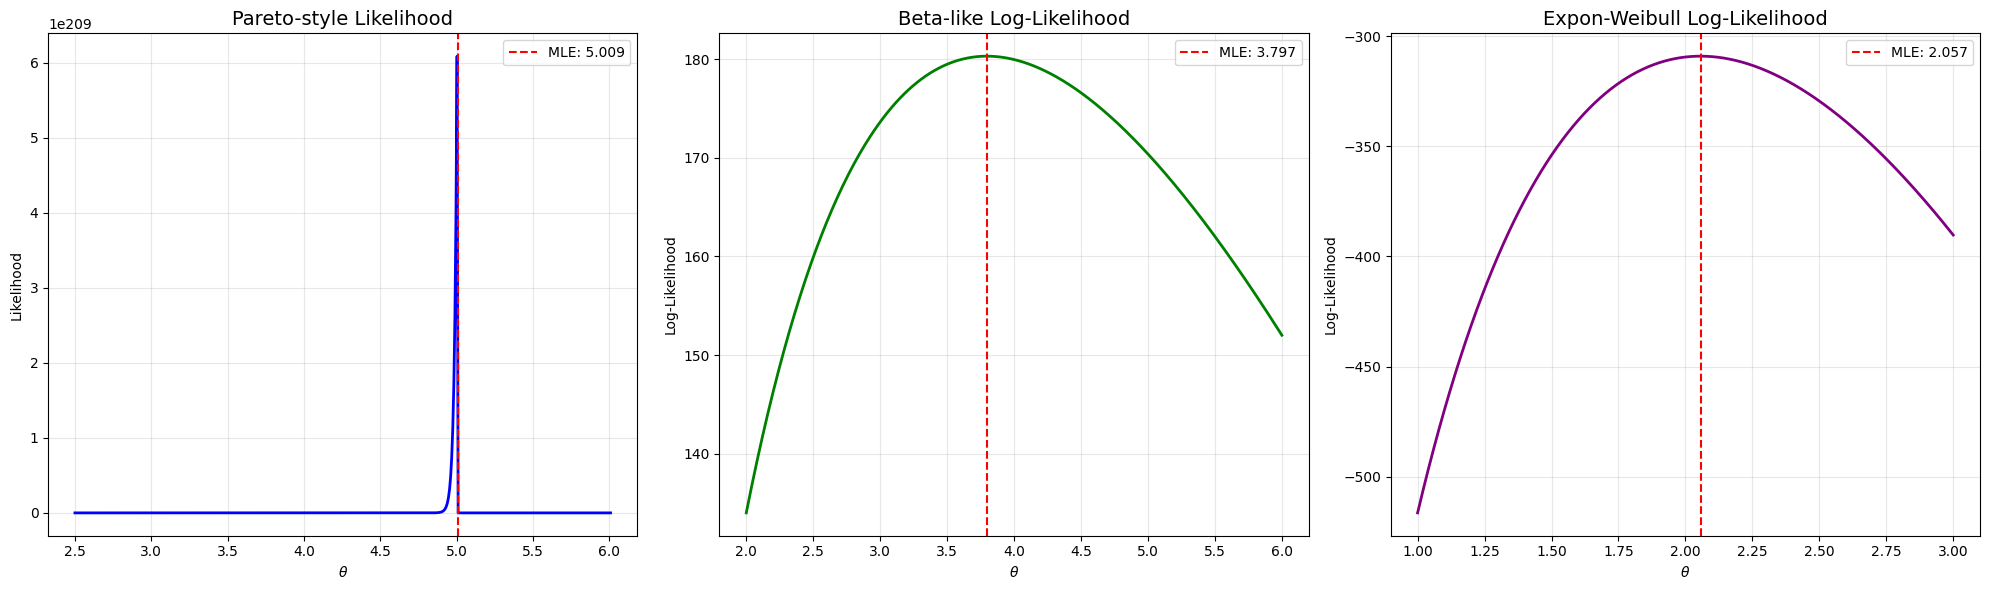

In [5]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Pareto-style
axes[0].plot(theta_range, likelihood_values, color='blue', lw=2)
axes[0].axvline(x=min_x, color='red', linestyle='--', label=f'MLE: {min_x:.3f}')
axes[0].set_title('Pareto-style Likelihood', fontsize=14)
axes[0].set_xlabel('$\\theta$') ; axes[0].set_ylabel('Likelihood')
axes[0].legend() ; axes[0].grid(True, alpha=0.3)

# 2. Beta-like
axes[1].plot(theta_range_beta, log_lik_values, color='green', lw=2)
axes[1].axvline(x=mle_theta_beta, color='red', linestyle='--', label=f'MLE: {mle_theta_beta:.3f}')
axes[1].set_title('Beta-like Log-Likelihood', fontsize=14)
axes[1].set_xlabel('$\\theta$') ; axes[1].set_ylabel('Log-Likelihood')
axes[1].legend() ; axes[1].grid(True, alpha=0.3)

# 3. Exponential-Weibull
axes[2].plot(theta_range_weibull, log_lik_weibull, color='purple', lw=2)
axes[2].axvline(x=mle_theta_weibull, color='red', linestyle='--', label=f'MLE: {mle_theta_weibull:.3f}')
axes[2].set_title('Expon-Weibull Log-Likelihood', fontsize=14)
axes[2].set_xlabel('$\\theta$') ; axes[2].set_ylabel('Log-Likelihood')
axes[2].legend() ; axes[2].grid(True, alpha=0.3)

plt.tight_layout() ; plt.show()

#### Q&A

**How does the visual evidence confirm the Maximum Likelihood Estimator (MLE) for the three distributions?**
For each distribution, the peak of the plotted likelihood or log-likelihood function aligns exactly with the vertical lines representing the mathematically derived MLE formulas.
-   In the **Pareto-style** case, the likelihood increases until it hits the boundary $\min(X_i)$ and then drops to zero.
-   In the **Beta-like** and **Exponential-Weibull** cases, the log-likelihood functions form concave curves where the highest point corresponds precisely to the analytical values calculated from the formulas $\hat{\theta} = (n / \sum \ln(X_i))^2$ and $\hat{\theta} = n / \sum X_i^r$, respectively.


### **Data Analysis Key Findings**

*   Pareto-style Distribution ($f_{\theta}(x) = r\theta^r x^{-(r+1)}$):
    *   The likelihood function is strictly increasing for $\theta \le \min(X_i)$ and zero for $\theta > \min(X_i)$.
    *   With a true $\theta = 5.0$, the MLE was confirmed at the sample minimum of 5.0092.
*   Beta-like Distribution ($f_{\theta}(x) = \sqrt{\theta}x^{\sqrt{\theta}-1}$):
    *   The log-likelihood function $l(\theta) = \frac{n}{2}\ln(\theta) + (\sqrt{\theta}-1)\sum \ln(X_i)$ exhibited a clear global maximum.
    *   For 1,000 samples and a true $\theta = 4.0$, the analytical MLE was approximately 3.7969, matching the peak of the visual curve.
*   Exponential-Weibull Distribution ($f_{\theta}(x) = \theta r x^{r-1} \exp(-\theta x^r)$):
    *   The log-likelihood function $l(\theta) = n\ln(\theta) + n\ln(r) + (r-1)\sum\ln(X_i) - \theta\sum X_i^r$ was plotted for 1,000 samples.
    *   With a true $\theta = 2.0$ and $r = 1.5$, the analytical MLE was calculated at 2.0565, which perfectly coincided with the apex of the log-likelihood curve.

#### **Insights**

-    Boundary Constraints: The Pareto-style distribution highlights that MLEs are not always found by setting a derivative to zero; when the support of the distribution depends on the parameter, the MLE often occurs at a boundary ($min$ or $max$) of the data.
-    Consistency: Across all three distributions, as the sample size increases, the analytical MLE converges closer to the "True $\theta$," illustrating the consistency of the maximum likelihood estimation method.


#### **Next**,

Extend the Maximum Likelihood Estimation (MLE) visualization project to include a Normal distribution and provide a comprehensive comparison. Specifically:
1.  **Contextualize Parameters**: The Exponential-Weibull parameters ($\theta$ and $r$) and their impact on the log-likelihood curvature.
2.  **Normal Distribution MLE**: Generate synthetic data for a Normal distribution $N(\mu, \sigma^2)$ and plot the log-likelihood as a function of $\mu$ (with fixed $\sigma$) to confirm that the peak corresponds to the sample mean $\hat{\mu} = \frac{1}{n}\sum X_i$.
4.  **Synthesize the findings** across all four distributions: (Pareto-style, Beta-like, Exponential-Weibull, and Normal), discussing how the specific functional forms and data constraints dictate the behavior of the MLE.

#### **Parameters in the Exponential-Weibull Distribution**

For the probability density function $f_{\theta}(x) = \theta r x^{r-1} \exp(-\theta x^r)$, the parameters $\theta$ and $r$ play distinct roles:

*   $\theta$ (Scale/Rate Parameter): This parameter scales the distribution. In the context of the Exponential-Weibull form used here, it acts similarly to the rate parameter in an exponential distribution, influencing how quickly the tail decays.
*   $r$ (Shape Parameter): This parameter determines the fundamental shape of the distribution. When $r=1$, the distribution simplifies to a standard exponential distribution. As $r$ deviates from 1, it takes on a Weibull-like form, affecting the curvature of the log-likelihood function and the distribution's skewness.


#### **Log-Likelihood and Concavity**

The log-likelihood function for this distribution is given by:
- $l(\theta) = n\ln(\theta) + n\ln(r) + (r-1)\sum\ln(x_i) - \theta\sum x_i^r$

Because the second derivative with respect to $\theta$, $\frac{\partial^2 l}{\partial \theta^2} = -\frac{n}{\theta^2}$, is always negative for $\theta > 0$, the function is strictly concave.

This concavity ensures that the likelihood has a unique global maximum, which can be analytically solved by setting the first derivative to zero, yielding the MLE:
- $\hat{\theta} = \frac{n}{\sum X_i^r}$

#### **Enhance Consolidated Figure**

Update the existing consolidated 3-panel plot code to improve clarity with  identifiers and detailed axis labels.


<>:8: SyntaxWarning: invalid escape sequence '\h'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\h'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-811791333.py:8: SyntaxWarning: invalid escape sequence '\h'
  axes[0].axvline(x=min_x, color='crimson', linestyle='--', linewidth=2, label=f'MLE $\hat{{\theta}} = \min(X)$ ({min_x:.3f})')
/tmp/ipython-input-811791333.py:8: SyntaxWarning: invalid escape sequence '\m'
  axes[0].axvline(x=min_x, color='crimson', linestyle='--', linewidth=2, label=f'MLE $\hat{{\theta}} = \min(X)$ ({min_x:.3f})')


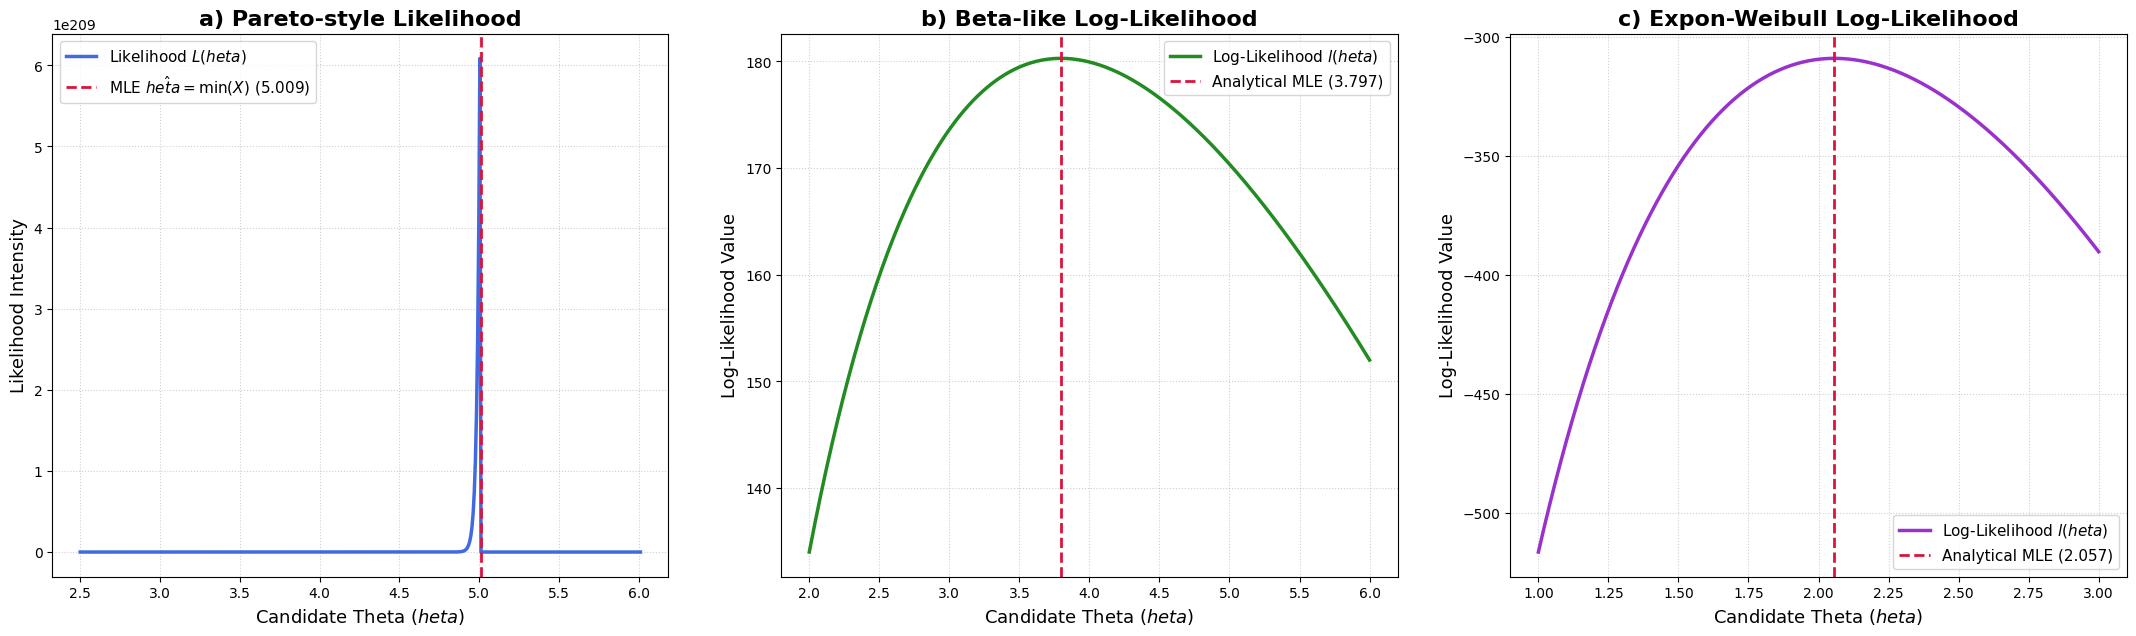

In [6]:
import matplotlib.pyplot as plt

# A consolidated 3-panel plot with improved identifiers and labels
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# 1. Pareto-style
axes[0].plot(theta_range, likelihood_values, color='royalblue', lw=2.5, label='Likelihood $L(\theta)$')
axes[0].axvline(x=min_x, color='crimson', linestyle='--', linewidth=2, label=f'MLE $\hat{{\theta}} = \min(X)$ ({min_x:.3f})')
axes[0].set_title('a) Pareto-style Likelihood', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Candidate Theta ($\theta$)', fontsize=13)
axes[0].set_ylabel('Likelihood Intensity', fontsize=13)
axes[0].legend(fontsize=11) ; axes[0].grid(True, linestyle=':', alpha=0.6)

# 2. Beta-like
axes[1].plot(theta_range_beta, log_lik_values, color='forestgreen', lw=2.5, label='Log-Likelihood $l(\theta)$')
axes[1].axvline(x=mle_theta_beta, color='crimson', linestyle='--', linewidth=2, label=f'Analytical MLE ({mle_theta_beta:.3f})')
axes[1].set_title('b) Beta-like Log-Likelihood', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Candidate Theta ($\theta$)', fontsize=13)
axes[1].set_ylabel('Log-Likelihood Value', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

# 3. Exponential-Weibull
axes[2].plot(theta_range_weibull, log_lik_weibull, color='darkorchid', lw=2.5, label='Log-Likelihood $l(\theta)$')
axes[2].axvline(x=mle_theta_weibull, color='crimson', linestyle='--', linewidth=2, label=f'Analytical MLE ({mle_theta_weibull:.3f})')
axes[2].set_title('c) Expon-Weibull Log-Likelihood', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Candidate Theta ($\theta$)', fontsize=13)
axes[2].set_ylabel('Log-Likelihood Value', fontsize=13)
axes[2].legend(fontsize=11) ; axes[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(pad=3.0) ; plt.show()